# PPO from scratch — **V2: Fixed-horizon buffer + bootstrapping**

Third of six. V1 gave you a learned baseline. V2 changes *how you collect data* and *how you close
off a trajectory you didn't get to finish*.

| Version | Concept |
|---|---|
| V0 | Vanilla PG |
| V1 | Learned value baseline (critic) |
| **V2 (this)** | **Fixed-horizon rollout buffer + bootstrapping on cutoff** |
| V3 | GAE-λ advantage |
| V4 | PPO-clip surrogate + multiple update passes |
| V5 | KL early-stop + advantage normalization |

### Why change anything — V1 already works?
Two reasons, one practical and one structural.

**Practical:** V1 collected a fixed *number of episodes* (32). Early on those are 500 steps each
(16000 transitions/epoch); once it's solving, they're ~90 steps (under 3000). Your data budget
swings ~6× epoch to epoch. Fixing the number of *steps* per epoch makes each update use a constant,
predictable amount of data.

**Structural (the real point):** once you collect a fixed step budget, an episode can get **chopped
off** — by the epoch boundary, or by the env's own 500-step timeout — before it truly ends. You
cannot Monte-Carlo the reward-to-go of a tail you never observed. So you **bootstrap**: use the
critic's `V(s_last)` as a stand-in for "the return the rest of the episode would have earned." This
is the machinery GAE (V3) and PPO (V4) are built on.

### The one distinction that matters: why did this path end?
- **Genuine terminal** — Acrobot's goal was reached. The episode is *really* over, no future reward
  exists → bootstrap value **= 0**.
- **Timeout** — the env hit its 500-step `TimeLimit` (gymnasium returns `truncated=True` from `step`).
  The episode was cut artificially → bootstrap **= V(s_last)**.
- **Epoch budget exhausted** mid-episode — also an artificial cut → bootstrap **= V(s_last)**.

Only the genuine terminal gets 0. Treating a timeout as a true terminal tells the critic "return
stopped here" when it didn't — a real bug that quietly biases everything toward pessimism.

### What you build in V2
1. A **`RolloutBuffer`** that stores transitions and, at each path boundary, turns rewards +
   a bootstrap value into reward-to-go targets.
2. A **fixed-horizon `train_one_epoch`**: roll out `STEPS_PER_EPOCH` steps, evaluate `V(s)` *at
   rollout time* (you need it for both bootstrapping and the baseline — this is the "advantage
   from rollout-time values" you set up in V1, now structural), and finish each path with the
   right bootstrap value.

Advantage is still `returns − V(s)` and the two-optimizer update is unchanged from V1.

### ✅ Done-when
- The **buffer unit test** (given) passes — your bootstrapping math is exact.
- The reliable "it works" signals are the **`goals` column climbing** (0 → ~45) and the **training
  return reaching ≈ −85** — that's the buffer + bootstrapping doing their job.
- Greedy eval **mean** stays in V1 territory (≈ −80 to −120 across seeds), but its **± can be wide
  at 15 epochs** — on seed 0 it's ~±60–80. A deterministic policy still hits the odd Acrobot limit
  cycle (exactly the V0 effect); it's seed luck, not a bug. If the *mean* craters or `goals` stays
  near 0, then your terminal-vs-timeout bootstrap is genuinely wrong.

> Kernel: `ppo`. Policy, critic, losses, and the eval harness are your V1 code, unchanged.


## Imports & configuration *(given — V2 swaps in a step budget)*

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.distributions.categorical import Categorical
import torch.nn.functional as F
import gymnasium as gym
from gymnasium.spaces import Discrete, Box

ENV_NAME   = "Acrobot-v1"
SEED       = 0
HIDDEN     = [64, 64]
LR         = 1e-2
EPOCHS     = 15
GAMMA      = 0.99

# ---- NEW in V2 --------------------------------------------------------------
STEPS_PER_EPOCH = 4000     # fixed transitions collected per epoch (replaces "32 episodes")

VALUE_LR        = 1e-2
VALUE_FIT_ITERS = 80

print("gymnasium", gym.__version__, "| torch", torch.__version__)

gymnasium 1.3.0 | torch 2.13.0+cpu


## Policy, critic, losses, helpers *(given — your V1 code, unchanged)*

In [2]:
class MyPolicy(nn.Module):
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN + [output_size]
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers = layers[:-1]
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> Categorical:
        return Categorical(logits=self.linear_layers(x))

    def greedy(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).argmax()

    def sample(self, x: torch.Tensor) -> torch.Tensor:
        return self(x).sample()


class MyCritic(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(nn.Linear(in_sz, out_sz))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(HIDDEN[-1], 1))
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).squeeze(-1)


def reward_to_go(rews: list[float], gamma: float = GAMMA) -> list[float]:
    """Discounted reward-to-go for a sequence. Handy for the buffer: append a bootstrap
    value to the rewards, take reward_to_go, and drop the last element."""
    n = len(rews)
    gamma_pows = gamma ** np.arange(n)
    cum_rews = []
    for i in range(n):
        left = n - i
        cr = (np.asarray(rews[i:]) * gamma_pows[:left]).sum()
        cum_rews.append(cr)
    return cum_rews


def compute_loss(policy: MyPolicy, obs: torch.Tensor, act: torch.Tensor,
                 weights: torch.Tensor) -> torch.Tensor:
    logp = policy(obs).log_prob(act)
    return -((logp) * weights).mean()


def compute_value_loss(critic: MyCritic, obs: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(critic(obs), returns)


def make_env(env_name: str = ENV_NAME, render_mode: str | None = None) -> gym.Env:
    return gym.make(env_name, render_mode=render_mode)


def set_seed(env: gym.Env, seed: int = SEED) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    env.action_space.seed(seed)


_e = make_env()
OBS_DIM = _e.observation_space.shape[0]
N_ACTS  = _e.action_space.n
MAX_STEPS = _e.spec.max_episode_steps
print(f"{ENV_NAME}: obs_dim={OBS_DIM}, n_acts={N_ACTS}, max_steps={MAX_STEPS}")
_e.close()

Acrobot-v1: obs_dim=6, n_acts=3, max_steps=500


## 1. The rollout buffer *(you implement)*

Build a `RolloutBuffer` that accumulates a fixed number of transitions and converts each finished
path into value targets. Suggested contract (the unit test below uses exactly this API):

- `RolloutBuffer(obs_dim, size, gamma)` — preallocate storage for `size` transitions.
- `store(obs, act, rew, val)` — save one transition (`val` is the rollout-time `V(s)`).
- `finish_path(last_val=0.0)` — for the path just completed (everything since the previous
  `finish_path`), compute its **bootstrapped reward-to-go**: append `last_val` to that path's
  rewards, take the discounted reward-to-go, and store it as the return target. `last_val` is `0`
  for a genuine terminal and `V(s_last)` for a cutoff — *the caller decides which*.
- `get()` — assert the buffer is full, then return the batch as tensors
  `dict(obs=..., act=..., ret=..., val=...)` and reset the pointers for the next epoch.

Reuse your `reward_to_go` for the per-path math. Keep `store`/`finish_path` cheap — you call
`store` a few thousand times an epoch.

In [3]:
class RolloutBuffer:
    
    # TODO (V2): fixed-size storage for one epoch of transitions.
    #   __init__(obs_dim, size, gamma): arrays for obs/act/rew/val/ret; a write pointer and a
    #                                   marker for where the current path started.
    #   store(obs, act, rew, val):      write one transition, advance the pointer.
    #   finish_path(last_val=0.0):      turn this path's rewards (+ last_val bootstrap) into
    #                                   reward-to-go targets; move the path marker to the pointer.
    #   get():                          assert full; return dict of tensors; reset pointers.
    def __init__(self, max_steps: int) -> None:
        self.obs_buffer = []
        self.actions_buffer = []
        self.rewards_buffer = []
        self.trajectory_raw_rewards = []
        self.max_steps = max_steps

    def append(self, obs: torch.Tensor, action: int, reward: float) -> None:
        self.obs_buffer.append(obs)
        self.actions_buffer.append(action)
        self.trajectory_raw_rewards.append(reward)
    
    def finish_trajectory(self, terminal_value: float) -> None:
        if len(self.trajectory_raw_rewards) > 0:
            accumulated_rewards = reward_to_go(self.trajectory_raw_rewards + [terminal_value])
            self.rewards_buffer += accumulated_rewards[:-1]
            self.trajectory_raw_rewards = []

    def full(self) -> bool:
        return len(self.obs_buffer) >= self.max_steps
    
    def get_data(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        obs_batch_tensor = torch.stack(self.obs_buffer)
        actions_tensor = torch.tensor(self.actions_buffer)
        rewards_tensor = torch.tensor(self.rewards_buffer, dtype=torch.float32)
        return obs_batch_tensor, actions_tensor, rewards_tensor
    


### 🔬 Unit test — bootstrapping is exact *(given)*

In [4]:
def _test_buffer() -> None:
    # Your buffer has no per-buffer gamma -- finish_trajectory relies on reward_to_go's
    # default, the global GAMMA. So the test pins the bootstrapping math at g = GAMMA.
    g = GAMMA
    buf = RolloutBuffer(max_steps=5)
    for r in [-1.0, -1.0, -1.0]:               # path A: genuine terminal -> bootstrap 0
        buf.append(torch.zeros(2), 0, r)
    buf.finish_trajectory(0.0)
    for r in [-1.0, -1.0]:                      # path B: cut off -> bootstrap V=5
        buf.append(torch.zeros(2), 0, r)
    buf.finish_trajectory(5.0)
    obs, act, ret = buf.get_data()
    ret = np.asarray(ret, dtype=np.float64)
    expA = [-1 - g - g**2, -1 - g, -1.0]                    # last_val 0  -> plain reward-to-go
    expB = [-1 + g*(-1) + g**2*5, -1 + g*5]                 # last_val 5  -> bootstrapped (kept real reward + gamma*V)
    np.testing.assert_allclose(ret[:3], expA, rtol=1e-6)
    np.testing.assert_allclose(ret[3:], expB, rtol=1e-6)
    assert obs.shape[0] == 5, "get_data() must return all transitions"
    print("buffer bootstrapping OK:", np.round(ret, 3))

_test_buffer()


buffer bootstrapping OK: [-2.97  -1.99  -1.     2.911  3.95 ]


## 2. Fixed-horizon rollout *(you implement)*

Rewrite `train_one_epoch` to collect a **fixed `STEPS_PER_EPOCH` budget** instead of whole
episodes. The skeleton of one step:

- ask the critic for `V(obs)` and the policy for an action (both under `no_grad`), **store the
  transition with that rollout-time value**, step the env.
- Decide whether the current path ends here, and if so with what bootstrap value:
  - a **genuine terminal** (goal) → `finish_path(0.0)`;
  - a **timeout** (`truncated=True` from `step`, without `terminated`) or the **epoch budget running out** mid-episode
    → `finish_path(V(s_last))`.
- Only count an episode's return/length toward the printed stats when it *actually ended*
  (`done`), not when the epoch boundary chopped it. Reset and keep going until the budget is spent.

Then update exactly as in V1: `data = buf.get()`, `advantages = ret − val` (val are your
rollout-time values — no second critic pass needed), one policy step on the advantages, and
`VALUE_FIT_ITERS` critic steps regressing to `ret`.

Return `(batch_rets, batch_lens, v_loss, n_goals)` where `n_goals` counts genuine terminals this
epoch — a satisfying Acrobot progress signal.

In [5]:
def train_one_epoch(env: gym.Env, policy_net: MyPolicy, critic_net: MyCritic,
                    policy_optimizer: Adam, critic_optimizer: Adam,
                    ) -> tuple[list[float], list[int], float, int]:
    # TODO (V2): fixed-horizon rollout into `buf` with correct bootstrapping (see above),
    #            then the V1 update (advantage = ret - val; policy step; critic fit).
    #            Return (batch_rets, batch_lens, v_loss, n_goals).
    buffer = RolloutBuffer(STEPS_PER_EPOCH)
    n_goals = 0
    batch_lens =[]
    batch_rets = []
    while not buffer.full():
        obs = torch.tensor(env.reset()[0], dtype = torch.float32)
        done = False
        while not done:
            with torch.no_grad():
                action =int( policy_net.sample(obs))
            next_obs, rew, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            timeout = truncated and not terminated
            buffer.append(obs,action, rew)
            obs = torch.tensor(next_obs, dtype = torch.float32)

            if buffer.full() and not done:
                done, timeout = True, True
            if done:
                if not buffer.full():
                    batch_lens.append(len(buffer.trajectory_raw_rewards))
                    batch_rets.append(sum(buffer.trajectory_raw_rewards))
                if not timeout:
                    final_v = 0
                    n_goals +=1
                else:
                    with torch.no_grad():
                        final_v = critic_net(obs).item()
                buffer.finish_trajectory(final_v)
    obs_batch_tensor, actions_tensor, rewards_tensor = buffer.get_data()
    with torch.no_grad():
        values = critic_net(obs_batch_tensor)
    for _ in range(VALUE_FIT_ITERS):
        critic_optimizer.zero_grad()
        critic_loss = compute_value_loss(critic_net, obs_batch_tensor, rewards_tensor)
        critic_loss.backward()
        critic_optimizer.step()
    
  
    policy_optimizer.zero_grad()
    loss = compute_loss(policy_net, obs_batch_tensor, actions_tensor, rewards_tensor - values )
    loss.backward()
    policy_optimizer.step()
        
    return batch_rets, batch_lens, critic_loss.item(), n_goals
                
    


## Evaluation & recording harness *(given — your V1 code, inline GIF)*

In [6]:
def greedy_action(obs: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return policy_net.greedy(torch.tensor(obs, dtype=torch.float32))


def evaluate(env_name: str = ENV_NAME, n_episodes: int = 10, seed: int = 1000) -> tuple[float, float]:
    """Average greedy return over n_episodes. Our comparison metric."""
    env = make_env(env_name)
    rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            obs, r, terminated, truncated, _ = env.step(greedy_action(obs))
            done = terminated or truncated
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def record_gif(out_path: str, env_name: str = ENV_NAME, episodes: int = 3, fps: int = 15) -> None:
    """Greedy rollout -> GIF saved to disk AND shown inline (animated) in the notebook."""
    try:
        import imageio
        env = make_env(env_name, render_mode="rgb_array")
        frames = []
        for _ in range(episodes):
            obs, done = env.reset()[0], False
            while not done:
                frames.append(env.render())
                obs, _, terminated, truncated, _ = env.step(greedy_action(obs))
                done = terminated or truncated
        env.close()
        imageio.mimsave(out_path, frames, fps=fps)
        print(f"saved {len(frames)} frames -> {out_path}")
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception as ex:
        print("record_gif skipped (likely headless):", repr(ex))

## Train *(given — drives your code)*

In [7]:
env = make_env()
set_seed(env, SEED)

policy_net = MyPolicy(OBS_DIM, N_ACTS)
policy_optimizer  = Adam(policy_net.parameters(), lr=LR)

critic_net = MyCritic(OBS_DIM)
critic_optimizer = Adam(critic_net.parameters(), lr=VALUE_LR)


for epoch in range(EPOCHS):
    batch_rets, batch_lens, v_loss, n_goals = train_one_epoch(env, policy_net, critic_net, policy_optimizer, critic_optimizer)
    avg_ret = np.mean(batch_rets) if len(batch_rets) else float("nan")
    avg_len = np.mean(batch_lens) if len(batch_lens) else float("nan")
    print("epoch %3d \t return %8.1f \t ep_len %6.1f \t v_loss %8.2f \t goals %3d" %
          (epoch, avg_ret, avg_len, v_loss, n_goals))
env.close()

epoch   0 	 return   -500.0 	 ep_len  500.0 	 v_loss  1570.97 	 goals   0


epoch   1 	 return   -293.2 	 ep_len  294.2 	 v_loss   483.56 	 goals  13


epoch   2 	 return   -262.6 	 ep_len  263.5 	 v_loss   332.05 	 goals  13


epoch   3 	 return   -180.5 	 ep_len  181.5 	 v_loss    85.47 	 goals  21


epoch   4 	 return   -141.2 	 ep_len  142.2 	 v_loss    49.46 	 goals  28


...

epoch  10 	 return    -87.0 	 ep_len   88.0 	 v_loss    66.65 	 goals  44


epoch  11 	 return   -100.7 	 ep_len  101.7 	 v_loss   299.28 	 goals  39


epoch  12 	 return    -86.0 	 ep_len   87.0 	 v_loss    90.52 	 goals  45


epoch  13 	 return    -79.8 	 ep_len   80.8 	 v_loss    30.55 	 goals  49


epoch  14 	 return    -89.4 	 ep_len   90.4 	 v_loss   134.58 	 goals  44


## ✅ Verify V2 *(given)*

advantage: mean +0.68  std 10.83  frac>0 0.64  min -47.2  max 27.7



V2 greedy return on Acrobot-v1: -85.0 +/- 30.1
Should stay in V1 territory -- V2 is a structural refactor, not a boost.


saved 246 frames -> v2_baseline.gif


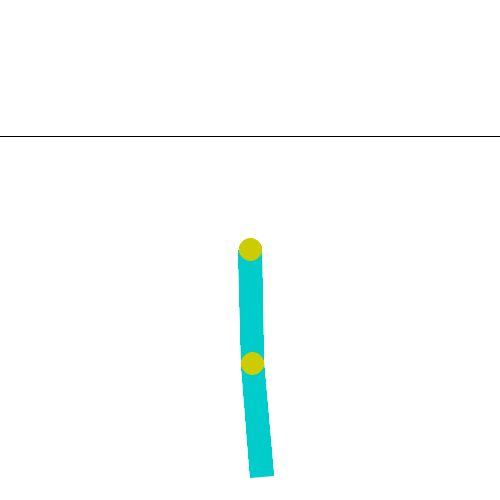

In [8]:
# advantage diagnostic on a fresh fixed-horizon batch built from the trained nets
def advantage_stats(steps: int = STEPS_PER_EPOCH) -> None:
    b = RolloutBuffer(steps)
    e = make_env(); o = e.reset()[0]
    for t in range(steps):
        obs_t = torch.tensor(o, dtype=torch.float32)
        with torch.no_grad():
            a = policy_net.sample(obs_t)
        o2, r, term, trunc, info = e.step(a)
        d = term or trunc
        b.append(obs_t, int(a), r)
        o = o2
        timeout = trunc and not term
        epoch_ended = t == steps - 1
        if d or epoch_ended:
            genuine = d and not timeout and not epoch_ended
            with torch.no_grad():
                last_v = 0.0 if genuine else critic_net(torch.tensor(o, dtype=torch.float32)).item()
            b.finish_trajectory(last_v)
            o = e.reset()[0]
    e.close()
    obs_b, act_b, ret_b = b.get_data()          # minimal buffer stores no val -> recompute from obs
    with torch.no_grad():
        val_b = critic_net(obs_b)
    adv = np.asarray(ret_b, np.float64) - np.asarray(val_b, np.float64)
    print(f"advantage: mean {adv.mean():+.2f}  std {adv.std():.2f}  frac>0 {(adv>0).mean():.2f}  "
          f"min {adv.min():.1f}  max {adv.max():.1f}")

advantage_stats()

mean_ret, std_ret = evaluate(n_episodes=30)
print(f"\nV2 greedy return on {ENV_NAME}: {mean_ret:.1f} +/- {std_ret:.1f}")
print("Should stay in V1 territory -- V2 is a structural refactor, not a boost.")
record_gif("v2_baseline.gif")


---
### When V2 is done
Ping me with your eval line + the `goals` progression and I'll review the bootstrapping (the
terminal-vs-timeout branch is where V2 bugs hide) before generating **V3 — GAE-λ**, which replaces
`ret − V(s)` with a λ-weighted blend of short- and long-horizon advantage estimates, buying a
smoother bias/variance trade-off on top of the exact buffer you just built.